# Tutorial 1.1: Top-Hat Synthetic Catalogs

This notebook is a companion to Tutorial 1. 

We cover:

1. The top-hat geometry and the role of theta_c
2. How to count the events seen by the Monte Carlo
3. How to generate GBM-like observables
4. How to generate observables with a custom sensitivity
5. How to keep E_iso and theta_c consistent in the catalogue

## Imports

In [9]:
%load_ext autoreload
%autoreload 2
import notebook_setup

import  emcee
import  numpy                   as np
import  pandas                  as pd
import  matplotlib.pyplot       as plt
from    math                    import inf
from    pathlib                 import Path
# Top-hat jet model specific modules
from    src.top_hat.montecarlo      import montecarlo, start_mcmc, apply_detection_cuts
from    src.top_hat.plot            import TopHatPlotter
from    src.utils                   import score_func_cvm, poiss_log, DEFAULT_LIMITS, create_run_dir
from    src.top_hat.init            import initialize_bns_simulation
from    src.top_hat.geometric_eff   import geometric_efficiency_flat, generate_theta_c_flat

# Apply custom plotting style
# plt.style.use('../configurations/style.mplstyle') if you have latex
# conda install -n acme_env -c conda-forge texlive-core dvipng cm-super if you want to use the latex style, otherwise use the default matplotlib style or a custom one without latex support. 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Why this tutorial exists

The top-hat model has a simple angular structure: a jet is bright only inside its opening angle. For a flat top-hat distribution, theta_c is drawn uniformly between 1 deg and theta_c_max. For a universal model, every jet shares the same theta_c.

For the energy column, we keep the distinction explicit:

- E_iso is the isotropic-equivalent energy inferred from the luminosity draw
- E_jet is the collimation-corrected energy, which depends on theta_c through 1 - cos(theta_c)

That dependence is the part that needs care in the non universal top-hat case.

## Setup and Priors

We keep the same flat-prior model as Tutorial 1. The only change is that the catalogue section later on uses a reusable event-count helper.

In [10]:
CUSTOM_EFFICIENCY = 0.6 # the GBM duty cycle + FOV change it to whatever you wish 
INPUT_LIMITS = DEFAULT_LIMITS.copy() # Change this to whatever you wish

In [11]:
datafiles   = Path('../datafiles')
output_dir  = create_run_dir('tutorial1_tophat_flat')

mrd_path                 = datafiles / "MRD_outputs/fiducial_A1_0_BNS.csv"
bns_data, observables    = initialize_bns_simulation(datafiles, mrd_path=mrd_path)

PARAM_NAMES = ['A_index', 'L_L0', 'L_mu_E', 'sigma_E', 'theta_c_max', 'fj']

Loading existing directory  : Output_files/tutorial1_tophat_flat
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 333, Trigger years: 17.94, Yearly rate: 18.57 events/year
BNS: R(z=0.01)=113.74 Gpc^-3 yr^-1; all-sky rate=3.568e+05 yr^-1; MC sample=356797


## MCMC and event accounting

The MCMC setup can stay the same as Tutorial 1. The important part for this notebook is the event-count helper below: it computes how many bursts the Monte Carlo actually needs to draw before any detection cuts are applied.

In [19]:
from scipy.stats import lognorm

BURN_IN = 200

def expected_tophat_events(theta, bns_data, n_years=4):
    _, _, _, _, theta_c_value, fj = theta
    gbm_eff                 = CUSTOM_EFFICIENCY
    geometric_efficiency    = geometric_efficiency_flat(theta_c_value)
    available_events        = np.ceil(n_years * len(bns_data.z_arr) * geometric_efficiency * gbm_eff * fj).astype(int) # make sure we have at least 1 event to simulate
    return available_events, geometric_efficiency

def draw_tophat_geometry(n_events, theta_c_value, rng = np.random.default_rng(42)):
    theta_c_gen     = generate_theta_c_flat(theta_c_value, n_samples=n_events)
    theta_view_deg  = np.degrees(np.arccos(rng.uniform(0.0, 1.0, size=n_events)))
    on_axis         = theta_view_deg <= theta_c_gen
    return theta_view_deg, theta_c_gen, on_axis

def make_tophat_catalog(theta, bns_data, 
                        n_years=4, limits=INPUT_LIMITS, duration_s=1.0, epsilon_factor = 0.3, seed=1234):

    theta_c_value       = theta[4]
    rng                 = np.random.default_rng(seed)
    n_events, geo_eff   = expected_tophat_events(theta, bns_data, n_years=n_years)
    mc                  = montecarlo(theta, n_events, bns_data, rng=rng)
    theta_view_deg, theta_c_deg, _ = draw_tophat_geometry(n_events, theta_c_value, rng=rng)

    observed_flux   = mc['p_flux']

    trigger_mask, analysis_mask = apply_detection_cuts(
        observed_flux,
        mc['E_p_obs'],
        pflux_min=limits['F_LIM'],
        epeak_range=(limits['EP_LIM_LOWER'], limits['EP_LIM_UPPER']),
    )

    print(sum(trigger_mask))

    final_mask = analysis_mask
    if np.sum(final_mask) == 0:
        return pd.DataFrame(columns=[
            'z', 'theta_view_deg', 'theta_c_deg', 'p_flux_ph_cm2_s', 'E_p_obs_keV',
            'log_10_E_iso_erg', 'log_10_E_jet_one_sided_erg'
        ])

    e_iso_erg           = mc['L_p_obs'] * duration_s * epsilon_factor #which is the median of the peak flux to average flux ratios in the GBM sample
    e_jet_one_sided_erg = e_iso_erg * (1.0 - np.cos(np.deg2rad(theta_c_deg)))

    catalog = pd.DataFrame({
        'z': mc['z_arr'][final_mask],
        'theta_view_deg': theta_view_deg[final_mask],
        'theta_c_deg': theta_c_deg[final_mask],
        'p_flux_ph_cm2_s': observed_flux[final_mask],
        'E_p_obs_keV': mc['E_p_obs'][final_mask],
        'log_10_E_iso_erg': np.log10(e_iso_erg[final_mask]),
        'log_10_E_jet_one_sided_erg': np.log10(e_jet_one_sided_erg[final_mask]),
    })

    catalog = catalog.sort_values(['z', 'theta_view_deg']).reset_index(drop=True)
    catalog.attrs['n_events_simulated'] = n_events
    catalog.attrs['geometric_efficiency'] = geo_eff
    return catalog

## Load a representative posterior sample

The catalogue examples below use the posterior median if a chain exists, otherwise they fall back to a representative parameter vector so the notebook remains usable even before the MCMC is run.

In [20]:
theta_demo      = np.array([3.0, 3.0, 3.0, 0.5, 10.0, 0.5])
samples         = None
backend_path    = output_dir / 'emcee.h5'

if backend_path.exists():
    backend = emcee.backends.HDFBackend(backend_path)
    try:
        samples = backend.get_chain(discard=BURN_IN, thin=10, flat=True)
        if len(samples) > 0:
            theta_demo = np.median(samples, axis=0)
    except Exception:
        pass

print(f'Using theta_demo = {theta_demo}')
print(f'Example geometric efficiency = {expected_tophat_events(theta_demo, bns_data)[1]:.4f}')

Using theta_demo = [3.87871796 3.04094244 3.43405075 0.3959571  8.46489593 0.83362606]
Example geometric efficiency = 0.0041


## GBM-like catalogue

This is the case you asked for first: draw the Monte Carlo population for the top-hat model, then keep only the events that survive the GBM-like cuts. The event count comes from the simulated population size, not from the observed catalogue rate.

For the flat top-hat model, theta_c is sampled event by event from 1 deg to theta_c_max.

In [21]:
N_YEARS = 10
gbm_catalog = make_tophat_catalog(
    theta=theta_demo,
    bns_data=bns_data,
    n_years=N_YEARS,
    limits=DEFAULT_LIMITS,
    duration_s=1.0,
)

display_cols = ['z', 'theta_view_deg', 'theta_c_deg', 'log_10_E_iso_erg', 'log_10_E_jet_one_sided_erg']
print(f'GBM-like detected events: {len(gbm_catalog)}')
simulated_draws = gbm_catalog.attrs.get('n_events_simulated', 'n/a')
print(f'Simulated draws: {simulated_draws}')
gbm_catalog[display_cols].head(10)

gbm_path = output_dir / 'tophat_catalog_gbm.csv'
gbm_catalog.to_csv(gbm_path, index=False)
print(f'Saved GBM-like catalogue to {gbm_path}')

250
GBM-like detected events: 250
Simulated draws: 7342
Saved GBM-like catalogue to Output_files/tutorial1_tophat_flat/tophat_catalog_gbm.csv


## Custom sensitivity catalogue

The same helper can be reused with different detector cuts. That makes the notebook suitable for the GBM case above and for a custom sensitivity curve or a different instrument threshold.

If you are using a universal opening angle model, switch theta_c_mode to 'fixed' and pass a theta_c value instead of theta_c_max.

In [22]:
CUSTOM_LIMITS = {
    'F_LIM': 1.0,
    'EP_LIM_LOWER': 20,
    'EP_LIM_UPPER': 20_000,
}

custom_catalog = make_tophat_catalog(
    theta=theta_demo,
    bns_data=bns_data,
    n_years=10,
    limits=CUSTOM_LIMITS,
    duration_s=1.0,
)

print(f'Custom-sensitivity detected events: {len(custom_catalog)}')
custom_catalog[['z', 'theta_view_deg', 'theta_c_deg', 'log_10_E_iso_erg', 'log_10_E_jet_one_sided_erg']].head(10)

custom_path = output_dir / 'tophat_catalog_custom_sensitivity.csv'
custom_catalog.to_csv(custom_path, index=False)
print(f'Saved custom-sensitivity catalogue to {custom_path}')

1347
Custom-sensitivity detected events: 1347
Saved custom-sensitivity catalogue to Output_files/tutorial1_tophat_flat/tophat_catalog_custom_sensitivity.csv


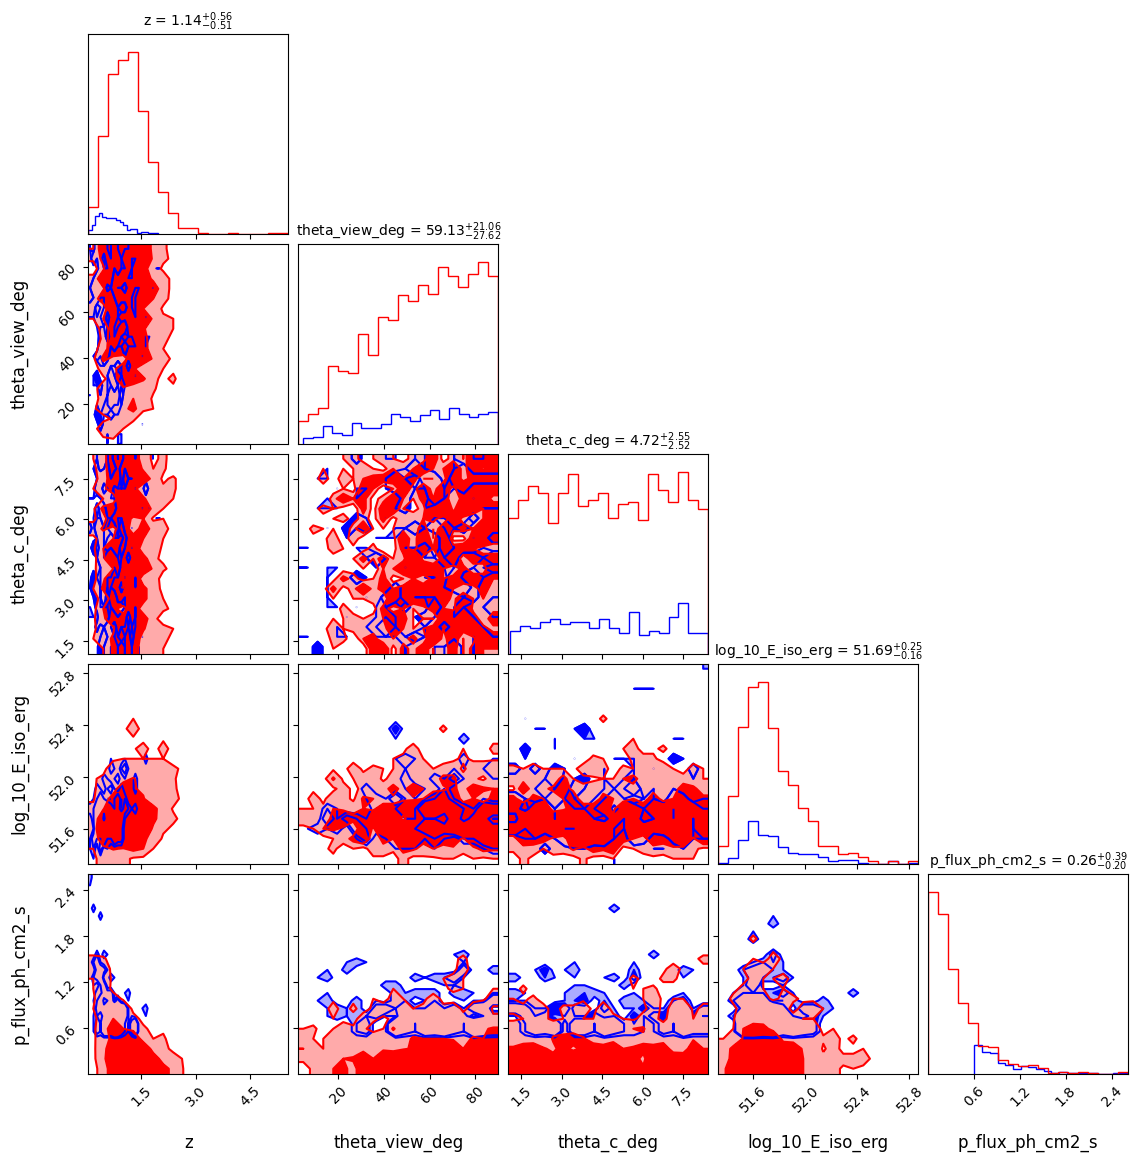

In [ ]:
# corner plot comparing the two catalogs
import corner

observables = ['z', 'theta_view_deg', 'theta_c_deg', 'log_10_E_iso_erg', 'p_flux_ph_cm2_s']
gbm_samples = gbm_catalog[observables].values
custom_samples = custom_catalog[observables].values

# log10 the pflux
gbm_samples[:, -1] = np.log10(gbm_samples[:, -1])
custom_samples[:, -1] = np.log10(custom_samples[:, -1])

figure = corner.corner(
    gbm_samples,
    labels=observables,
    color='blue',
    label_kwargs={'fontsize': 12},
    show_titles=True,
    title_kwargs={'fontsize': 10},
    plot_datapoints=False,
    fill_contours=True,
    levels=[0.68, 0.95],
    title_fmt='.2f',
)

corner.corner(
    custom_samples,
    labels=observables,
    color='red',
    label_kwargs={'fontsize': 12},
    show_titles=True,
    title_kwargs={'fontsize': 10},
    plot_datapoints=False,
    fill_contours=True,
    levels=[0.68, 0.95],
    title_fmt='.2f',
    fig=figure,
)

plt.show()